/kaggle/input/datasets/andrewmvd/lits-png/dataset_6/dataset_6/volume-2_0.png
/kaggle/input/datasets/andrewmvd/lits-png/dataset_6/dataset_6/segmentation-2_livermask_0.png


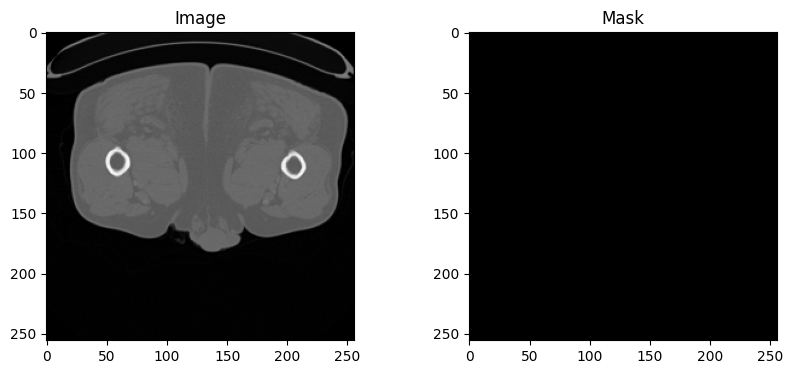

In [2]:
import pandas as pd
import cv2
import matplotlib.pyplot as plt

base = "/kaggle/input/datasets/andrewmvd/lits-png/dataset_6/dataset_6/"

df = pd.read_csv("/kaggle/input/datasets/andrewmvd/lits-png/lits_train.csv")

row = df.iloc[0]

img_path = row['filepath'].replace("../input/lits-png/dataset_6/", base)
mask_path = row['liver_maskpath'].replace("../input/lits-png/dataset_6/", base)

print(img_path)
print(mask_path)

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(mask, cmap='gray')

plt.show()

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class LiverDataset(Dataset):
    def __init__(self, df, base):
        self.df = df
        self.base = base

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = row['filepath'].replace("../input/lits-png/dataset_6/", self.base)
        mask_path = row['liver_maskpath'].replace("../input/lits-png/dataset_6/", self.base)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (128,128))
        mask = cv2.resize(mask, (128,128))

        img = img / 255.0
        mask = (mask >= 1).astype('float32')

        img = np.expand_dims(img, axis=0)
        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

In [16]:
df_small = df.sample(1000).reset_index(drop=True)

dataset = LiverDataset(df_small, base)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

In [17]:
images, masks = next(iter(loader))
print(images.shape)
print(masks.shape)

torch.Size([4, 1, 128, 128])
torch.Size([4, 1, 128, 128])


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [10]:
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

In [12]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(1, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.down4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(512, 1024)

        self.up1 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.conv1 = DoubleConv(1024, 512)

        self.up2 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv2 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv3 = DoubleConv(256, 128)

        self.up4 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv4 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        d4 = self.down4(p3)
        p4 = self.pool4(d4)

        b = self.bridge(p4)

        u1 = self.up1(b)
        u1 = torch.cat([u1, d4], dim=1)
        u1 = self.conv1(u1)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, d3], dim=1)
        u2 = self.conv2(u2)

        u3 = self.up3(u2)
        u3 = torch.cat([u3, d2], dim=1)
        u3 = self.conv3(u3)

        u4 = self.up4(u3)
        u4 = torch.cat([u4, d1], dim=1)
        u4 = self.conv4(u4)

        out = self.final(u4)
        return out

In [13]:
model = UNet().to(device)
print("Model created")

Model created


In [22]:
model.load_state_dict(torch.load("/kaggle/input/datasets/peace304/unet-pretrained-weights/model_unet.pth"))
print("Model loaded successfully")

Model loaded successfully


In [23]:
import torch.nn as nn
import torch.optim as optim

def dice_loss(pred, target, eps=1e-6):
    pred = torch.sigmoid(pred)
    
    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    
    dice = (2. * intersection + eps) / (union + eps)
    return 1 - dice.mean()

def combined_loss(pred, target):
    bce = nn.BCEWithLogitsLoss()(pred, target)
    dl = dice_loss(pred, target)
    return 0.5 * bce + 0.5 * dl

criterion = combined_loss

optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("Loss and optimizer ready")

Loss and optimizer ready


In [27]:
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader)}")

Epoch 1, Loss: 0.3826834808290005
Epoch 2, Loss: 0.3797978793680668
Epoch 3, Loss: 0.37823294949531555
Epoch 4, Loss: 0.3751350055038929
Epoch 5, Loss: 0.37495006576180456


5 + 5 total 10 epochs trained

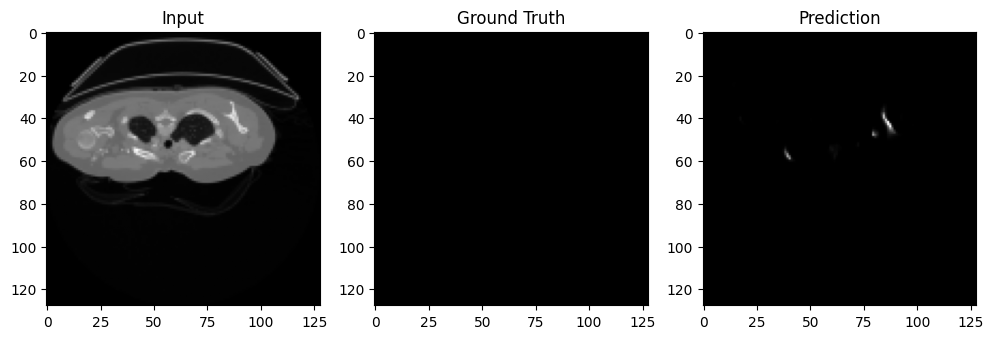

In [28]:
model.eval()

img, mask = dataset[0]

with torch.no_grad():
    pred = model(img.unsqueeze(0).to(device))
    pred = torch.sigmoid(pred)
    pred = pred.squeeze().cpu().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input")
plt.imshow(img.squeeze(), cmap='gray')

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(mask.squeeze(), cmap='gray')

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred, cmap='gray')

plt.show()

Using index: 8


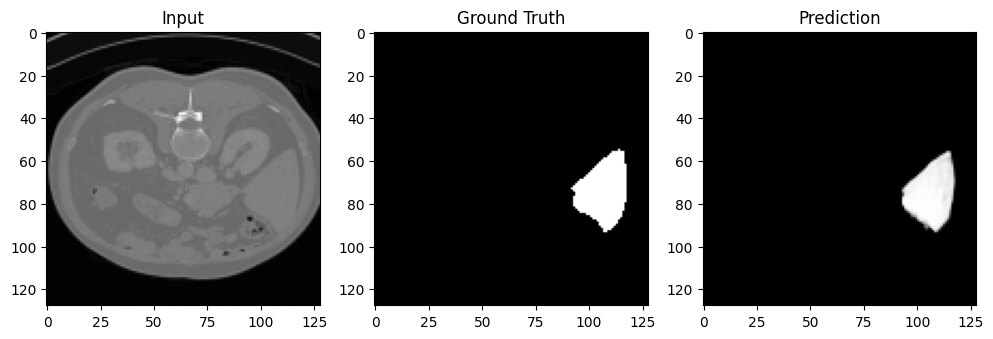

In [29]:
for i in range(50):
    img, mask = dataset[i]
    
    if mask.max() > 0:  # has liver
        print("Using index:", i)
        
        model.eval()
        with torch.no_grad():
            pred = model(img.unsqueeze(0).to(device))
            pred = torch.sigmoid(pred)
            pred = pred.squeeze().cpu().numpy()

        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.title("Input")
        plt.imshow(img.squeeze(), cmap='gray')

        plt.subplot(1,3,2)
        plt.title("Ground Truth")
        plt.imshow(mask.squeeze(), cmap='gray')

        plt.subplot(1,3,3)
        plt.title("Prediction")
        plt.imshow(pred, cmap='gray')

        plt.show()
        break

In [32]:
torch.save(model.state_dict(), "/kaggle/working/unet_finetuned_v2.pth")

In [37]:
model = UNet()

model.load_state_dict(
    torch.load("/kaggle/working/unet_finetuned_v2.pth", map_location=device)
)

model = model.to(device)
model.eval()

print("Model loaded again")

Model loaded again


# TransUNet

In [38]:
model = UNet()

model.load_state_dict(
    torch.load("/kaggle/working/unet_finetuned_v2.pth", map_location=device)
)

model = model.to(device)
model.eval()

print("Model loaded again")

Model loaded again


In [20]:
import torch.nn as nn

class SimpleTransUNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        # CNN encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU()
        )
        
        # Transformer-like attention (simplified)
        self.attention = nn.MultiheadAttention(embed_dim=64, num_heads=4, batch_first=True)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, 1)
        )

    def forward(self, x):
        b, c, h, w = x.shape

        x = self.encoder(x)

        # DOWN SAMPLE (critical fix)
        x = nn.functional.interpolate(x, size=(32, 32))  

        b, c, h_small, w_small = x.shape

        x_flat = x.view(b, c, -1).permute(0, 2, 1)

        x_attn, _ = self.attention(x_flat, x_flat, x_flat)

        x_attn = x_attn.permute(0, 2, 1).view(b, c, h_small, w_small)

        # UPSAMPLE BACK
        x_attn = nn.functional.interpolate(x_attn, size=(128, 128))

        out = self.decoder(x_attn)

        return out

In [48]:
transunet = SimpleTransUNet().to(device)
print("TransUNet ready")

TransUNet ready


In [52]:
def cascade_forward(img):
    with torch.no_grad():
        unet_out = torch.sigmoid(model(img))
    
    refined = transunet(unet_out)
    return refined

In [32]:
criterion2 = combined_loss
optimizer2 = torch.optim.Adam(transunet.parameters(), lr=1e-3)

In [56]:
epochs = 3

for epoch in range(epochs):
    transunet.train()
    total_loss = 0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        with torch.no_grad():
            unet_out = torch.sigmoid(model(images))

        outputs = transunet(unet_out)

        loss = criterion2(outputs, masks)

        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()

        total_loss += loss.item()

    print(f"TransUNet Epoch {epoch+1}, Loss: {total_loss/len(loader)}")

TransUNet Epoch 1, Loss: 0.4878053823113441
TransUNet Epoch 2, Loss: 0.3977298338413239
TransUNet Epoch 3, Loss: 0.39557963860034945


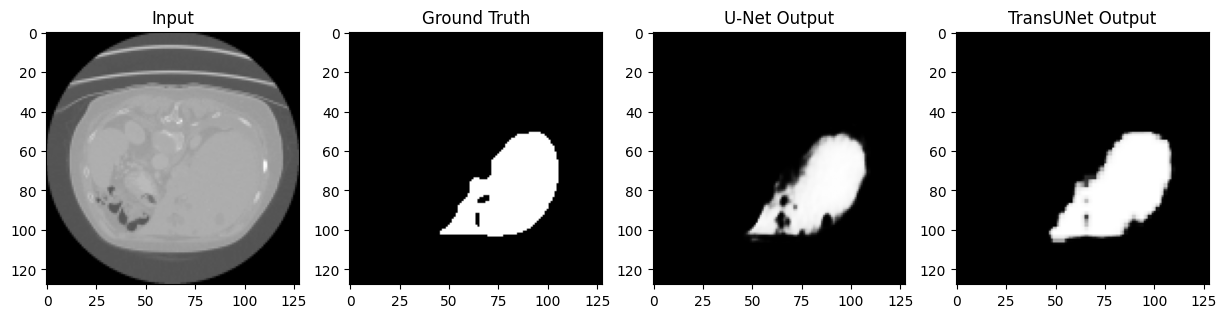

In [57]:
transunet.eval()

img, mask = dataset[10]

with torch.no_grad():
    unet_pred = torch.sigmoid(model(img.unsqueeze(0).to(device)))
    trans_pred = torch.sigmoid(transunet(unet_pred))

    unet_pred = unet_pred.squeeze().cpu().numpy()
    trans_pred = trans_pred.squeeze().cpu().numpy()

plt.figure(figsize=(15,4))

plt.subplot(1,4,1)
plt.title("Input")
plt.imshow(img.squeeze(), cmap='gray')

plt.subplot(1,4,2)
plt.title("Ground Truth")
plt.imshow(mask.squeeze(), cmap='gray')

plt.subplot(1,4,3)
plt.title("U-Net Output")
plt.imshow(unet_pred, cmap='gray')

plt.subplot(1,4,4)
plt.title("TransUNet Output")
plt.imshow(trans_pred, cmap='gray')

plt.show()

In [27]:
def dice_score(pred, target, eps=1e-6):
    pred = (pred > 0.5).float()
    
    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    
    dice = (2. * intersection + eps) / (union + eps)
    
    return dice.mean().item()

In [60]:
model.eval()
transunet.eval()

unet_dice = 0
trans_dice = 0
count = 0

for images, masks in loader:
    images = images.to(device)
    masks = masks.to(device)

    with torch.no_grad():
        # U-Net prediction
        unet_pred = torch.sigmoid(model(images))
        
        # TransUNet prediction
        trans_pred = torch.sigmoid(transunet(unet_pred))

    unet_dice += dice_score(unet_pred, masks)
    trans_dice += dice_score(trans_pred, masks)
    
    count += 1

print("U-Net Dice:", unet_dice / count)
print("TransUNet Dice:", trans_dice / count)

U-Net Dice: 0.7304613583087921
TransUNet Dice: 0.8028193240165711


In [64]:
torch.save(transunet.state_dict(), "/kaggle/working/transunet_final.pth")

# Experiment: Training with 3000 samples

In [7]:
df_non_empty = df[df['liver_maskpath'].notnull()]

df_large = df_non_empty.sample(3000).reset_index(drop=True)

print(len(df_large))

3000


In [8]:
dataset_large = LiverDataset(df_large, base)

loader_large = DataLoader(dataset_large, batch_size=2, shuffle=True)

In [21]:
model = UNet()
model.load_state_dict(
    torch.load("/kaggle/input/models/peace304/liver-segmentation-models/pytorch/default/1/unet_finetuned_v2.pth", map_location=device)
)
model = model.to(device)
model.eval()


transunet = SimpleTransUNet().to(device)
transunet.load_state_dict(
    torch.load("/kaggle/input/models/peace304/liver-segmentation-models/pytorch/default/1/transunet_final.pth", map_location=device)
)
transunet.eval()

print("Both models loaded")

Both models loaded


In [24]:
epochs = 2  # short fine-tuning

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, masks in loader_large:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"3000 Fine-tune Epoch {epoch+1}, Loss: {total_loss/len(loader_large)}")

3000 Fine-tune Epoch 1, Loss: 0.3835323695863287
3000 Fine-tune Epoch 2, Loss: 0.3775196031195422


In [28]:
model.eval()

dice_total = 0
count = 0

for images, masks in loader_large:
    images = images.to(device)
    masks = masks.to(device)

    with torch.no_grad():
        preds = torch.sigmoid(model(images))

    dice_total += dice_score(preds, masks)
    count += 1

print("U-Net Dice (3000):", dice_total / count)

U-Net Dice (3000): 0.8808346981932993


In [29]:
torch.save(model.state_dict(), "/kaggle/working/unet_3000_finetuned.pth")

In [33]:
epochs = 2

for epoch in range(epochs):
    transunet.train()
    total_loss = 0

    for images, masks in loader_large:
        images = images.to(device)
        masks = masks.to(device)

        with torch.no_grad():
            unet_out = torch.sigmoid(model(images))

        outputs = transunet(unet_out)

        loss = criterion2(outputs, masks)

        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()

        total_loss += loss.item()

    print(f"TransUNet 3000 Epoch {epoch+1}, Loss: {total_loss/len(loader_large)}")

TransUNet 3000 Epoch 1, Loss: 0.3760506730526686
TransUNet 3000 Epoch 2, Loss: 0.374727746044596


In [34]:
model.eval()
transunet.eval()

dice_total = 0
count = 0

for images, masks in loader_large:
    images = images.to(device)
    masks = masks.to(device)

    with torch.no_grad():
        # U-Net output
        unet_pred = torch.sigmoid(model(images))
        
        # TransUNet refinement
        trans_pred = torch.sigmoid(transunet(unet_pred))

    dice_total += dice_score(trans_pred, masks)
    count += 1

print("TransUNet Dice:", dice_total / count)

TransUNet Dice: 0.896468891895513


In [41]:
torch.save(transunet.state_dict(), "/kaggle/working/transunet_3000_final.pth")

In [36]:
torch.save({
    'unet': model.state_dict(),
    'transunet': transunet.state_dict()
}, "/kaggle/working/full_pipeline_3000.pth")

In [42]:
import zipfile

with zipfile.ZipFile('/kaggle/working/transunet_3000.zip', 'w') as zipf:
    zipf.write('/kaggle/working/transunet_3000_final.pth', arcname='transunet_3000_final.pth')